### Основная задача в данном разделе:
* Изучение датасета
* Проверка, клининг и анализ данных
* Выявление основных правил для последующих рассчетов
* EDA 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
ecom_df = pd.read_csv('ecom_data_ws_1604.csv')
ecom_df.head()

,Unnamed: 0,customer_id,purchase_date,product_category,product_price,quantity,payment_method,customer_age,gender
0,0,14853,2020-01-01 00:22:42,Books,93.0,2,PayPal,53,Male
1,1,16006,2020-01-01 00:34:38,Electronics,125.0,1,Credit Card,37,Female
2,2,14097,2020-01-01 00:51:33,Clothing,293.0,1,Credit Card,70,Male
3,3,11668,2020-01-01 01:07:45,Electronics,369.0,1,Credit Card,60,Male
4,4,8735,2020-01-01 01:38:01,Home,109.0,3,PayPal,39,Female


#### 1. Проведем небольшой клининг и проверку колонок/строк датасета

In [3]:
ecom_df = ecom_df.drop('Unnamed: 0', axis=1)
ecom_df['revenue'] = ecom_df['product_price'] * ecom_df['quantity'] #Удаляю не нужную колонку, создаю новую, для последующих рассчетов
ecom_df.head()

,customer_id,purchase_date,product_category,product_price,quantity,payment_method,customer_age,gender,revenue
0,14853,2020-01-01 00:22:42,Books,93.0,2,PayPal,53,Male,186.0
1,16006,2020-01-01 00:34:38,Electronics,125.0,1,Credit Card,37,Female,125.0
2,14097,2020-01-01 00:51:33,Clothing,293.0,1,Credit Card,70,Male,293.0
3,11668,2020-01-01 01:07:45,Electronics,369.0,1,Credit Card,60,Male,369.0
4,8735,2020-01-01 01:38:01,Home,109.0,3,PayPal,39,Female,327.0


In [4]:
ecom_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       50000 non-null  int64  
 1   purchase_date     50000 non-null  object 
 2   product_category  50000 non-null  object 
 3   product_price     50000 non-null  float64
 4   quantity          50000 non-null  int64  
 5   payment_method    50000 non-null  object 
 6   customer_age      50000 non-null  int64  
 7   gender            50000 non-null  object 
 8   revenue           50000 non-null  float64
dtypes: float64(2), int64(3), object(4)
memory usage: 3.4+ MB


In [5]:
ecom_df['purchase_date'] = pd.to_datetime(ecom_df['purchase_date']) 

In [6]:
ecom_df[['product_price', 'quantity', 'customer_age']].describe()

,product_price,quantity,customer_age
count,50000.00000,50000.000000,50000.000000
mean,254.20670,2.999560,43.983600
std,141.26151,1.414652,15.340421
min,10.00000,1.000000,18.000000
25%,132.00000,2.000000,31.000000
50%,253.00000,3.000000,44.000000
75%,376.00000,4.000000,57.000000
max,500.00000,5.000000,70.000000


In [7]:
ecom_df[ecom_df.duplicated() == True]

,customer_id,purchase_date,product_category,product_price,quantity,payment_method,customer_age,gender,revenue


#### 1.1 На этапе проверки данных не были выявлены аномальные значения, дубликаты, пропуски
* колонка 'Unnamed: 0' - удалена
* добавлена колонка 'revenue' - дальше часто пригодится в рассчетах

#### 2. Стоит понять, что здесь считается за транзакцию. 

Довольно рискованно группировать события по времени, хоть и стоит проверить - сколько событий проведенны в одно время (корзиночная покупка).

Почему рискованно? В нашем датасете нет конкретной колонки order_id - что было бы показателем 'корзиночной покупки'. Сейчас проверяем покупки по времени -> далее делаем вывод

In [8]:
ecom_df[ecom_df[['customer_id', 'purchase_date']].duplicated() == True]

,customer_id,purchase_date,product_category,product_price,quantity,payment_method,customer_age,gender,revenue


Округлим значения до минутных - для проверки

In [9]:
date_round_minutes = ecom_df.copy()
date_round_minutes['purchase_date'] = date_round_minutes['purchase_date'].dt.strftime('%Y-%m-%d %H:%M')

date_round_minutes[date_round_minutes[['customer_id', 'purchase_date']].duplicated() == True]

,customer_id,purchase_date,product_category,product_price,quantity,payment_method,customer_age,gender,revenue


Так как я еще не знаком с датасетом, на всякий случай проверю данные, может быть совподений нет вообще

In [10]:
date_round_hours = ecom_df.copy()
date_round_hours['purchase_date'] = date_round_hours['purchase_date'].dt.strftime('%Y-%m-%d %H')

date_round_hours[date_round_hours[['customer_id', 'purchase_date']].duplicated() == True]

,customer_id,purchase_date,product_category,product_price,quantity,payment_method,customer_age,gender,revenue
2307,494,2020-01-31 20,Home,497.0,3,Credit Card,62,Male,1491.0
21212,2956,2020-10-13 02,Clothing,177.0,3,PayPal,59,Female,531.0
32375,7209,2021-03-11 15,Home,401.0,3,Credit Card,27,Female,1203.0
42168,14713,2021-07-21 23,Electronics,82.0,5,Cash,69,Male,410.0


In [11]:
date_round_day = ecom_df.copy()
date_round_day['purchase_date'] = date_round_day['purchase_date'].dt.strftime('%Y-%m-%d')

date_round_day[date_round_day[['customer_id', 'purchase_date']].duplicated() == True]

,customer_id,purchase_date,product_category,product_price,quantity,payment_method,customer_age,gender,revenue
819,10626,2020-01-11,Books,69.0,1,Crypto,69,Female,69.0
1028,11304,2020-01-14,Books,69.0,2,Cash,49,Female,138.0
1251,10995,2020-01-17,Clothing,161.0,5,Credit Card,52,Female,805.0
1291,15874,2020-01-17,Electronics,164.0,1,Crypto,64,Male,164.0
2095,305,2020-01-29,Home,462.0,5,PayPal,69,Female,2310.0
...,...,...,...,...,...,...,...,...,...
45532,5701,2021-09-06,Home,271.0,4,PayPal,39,Male,1084.0
46139,17253,2021-09-14,Electronics,189.0,3,PayPal,25,Male,567.0
47151,13060,2021-09-28,Electronics,353.0,2,Crypto,55,Female,706.0
47295,12065,2021-09-30,Clothing,95.0,1,Cash,50,Female,95.0


#### 2.1 На данный момент делаю вывод, что одна строка - одна транзакция
Соответственно выручка = product_price * quantity

Но резонный вопрос: на каком уровне считаем выручку (клиенту или месяцу)? 

Т.к. для анализа метрик датасета, нам понадобятся оба показателя - сохраняем оба уровня

#### 3. Что относится к повторной покупке?
В нашем случае это либо покупка на следующий календарный день, либо следующая покупка.

Базируясь на данных таблицы date_round_day, в которой всего 93 пользователя совершили покупку в один день, можно сделать вывод, что особой разницы между ними не будет. Возьмем показатель:
* Повторная покупка - следующая покупка

#### 4. Кто 'уснувший' клиент?
Здесь следует проверить данные дат между покупками покупателей, у которых есть больше одной покупки

In [29]:
# Поиск пользователей совершивших более 1-й покупки
count_purchase = ecom_df.groupby('customer_id', as_index=False).customer_id.value_counts()
count_purchase_filtred = count_purchase.query('count > 1')


ecom_filtred = ecom_df.query('customer_id in @count_purchase_filtred.customer_id') # Фильтруем основной датасет
ecom_filtred = ecom_filtred.sort_values(['customer_id', 'purchase_date']) # Сортируем для выявления предыдущей транзакции

ecom_filtred['previus_purchase_date'] = ecom_filtred.groupby('customer_id')['purchase_date'].shift(1) #Берем предыдущую дату
ecom_filtred['days_between_purchase'] = (ecom_filtred['purchase_date'] - ecom_filtred['previus_purchase_date']).dt.days
                                        
ecom_filtred.head()

,customer_id,purchase_date,product_category,product_price,quantity,payment_method,customer_age,gender,revenue,age_segment,previus_purchase_date,days_between_purchase
31889,2,2021-03-05 14:30:42,Books,144.0,1,PayPal,27,Female,144.0,25-34,NaT,NaN
46537,2,2021-09-19 16:55:21,Books,98.0,4,PayPal,27,Female,392.0,25-34,2021-03-05 14:30:42,198.0
20091,3,2020-09-27 22:26:24,Electronics,402.0,2,Credit Card,23,Female,804.0,18-24,NaT,NaN
23260,3,2020-11-09 13:49:00,Clothing,372.0,3,Cash,23,Female,1116.0,18-24,2020-09-27 22:26:24,42.0
37754,3,2021-05-22 12:41:36,Books,132.0,5,Credit Card,23,Female,660.0,18-24,2020-11-09 13:49:00,193.0


In [30]:
intervals = ecom_filtred['days_between_purchase'].dropna()
intervals.describe()

count    31611.000000
mean       147.683844
std        126.723352
min          0.000000
25%         48.000000
50%        113.000000
75%        216.000000
max        672.000000
Name: days_between_purchase, dtype: float64

In [31]:
print(f"Доля возвратов в течение 60 дней: {(intervals <= 60).mean():.2%}")
print(f"Доля возвратов в течение 90 дней: {(intervals <= 90).mean():.2%}")
print(f"Доля возвратов в течение 120 дней: {(intervals <= 120).mean():.2%}")

Доля возвратов в течение 60 дней: 30.64%
Доля возвратов в течение 90 дней: 42.50%
Доля возвратов в течение 120 дней: 52.48%


#### 4.1 Порог для спящих
По данным датасета, можно создать порог для 'не активных' клиентов (именно 'не активных', а не 'ушедших') в 120 дней - захватывает более 50% покупателей

### Правила для последующих расчетов:
1. Одна строка - одно покупательское событие
2. Выручка = product_price * quantity, по клиентам и месяцам - в зависимости от метрики
3. Повторная покупка - следующая покупка
4. Не активный пользоватеь - не совершал покупку более 120 дней
5. Аномалии в product_price и quantity, требующие удаления, не выявлены.

#### Проведем небольшое исследование данных
1. Посмотрим на динамику выручки, числу событий и клиентов (как общее, так и уникальных) по месяцам

In [32]:
dynamics_per_month = ecom_df.copy()

dynamics_per_month['month'] = dynamics_per_month['purchase_date'].dt.strftime('%Y-%m')

count_events_customers = (
                      dynamics_per_month.groupby('month', as_index=False)
                      .agg(
                           event = ('purchase_date', 'count'),
                           unique_customers = ('customer_id', 'nunique'),
                           total_revenue = ('revenue', 'sum')
                      ).sort_values('month')
                     )

count_events_customers['revenue_per_customers'] = count_events_customers['total_revenue'] / count_events_customers['unique_customers']
count_events_customers

,month,event,unique_customers,total_revenue,revenue_per_customers
0,2020-01,2312,2162,1771076.0,819.184089
1,2020-02,2130,2022,1632942.0,807.587537
2,2020-03,2263,2139,1742383.0,814.578308
3,2020-04,2232,2095,1688183.0,805.815274
4,2020-05,2325,2194,1768882.0,806.236098
5,2020-06,2221,2101,1698555.0,808.450738
6,2020-07,2312,2177,1769096.0,812.630225
7,2020-08,2332,2210,1746872.0,790.439819
8,2020-09,2193,2079,1666381.0,801.530063
9,2020-10,2313,2171,1702339.0,784.126670


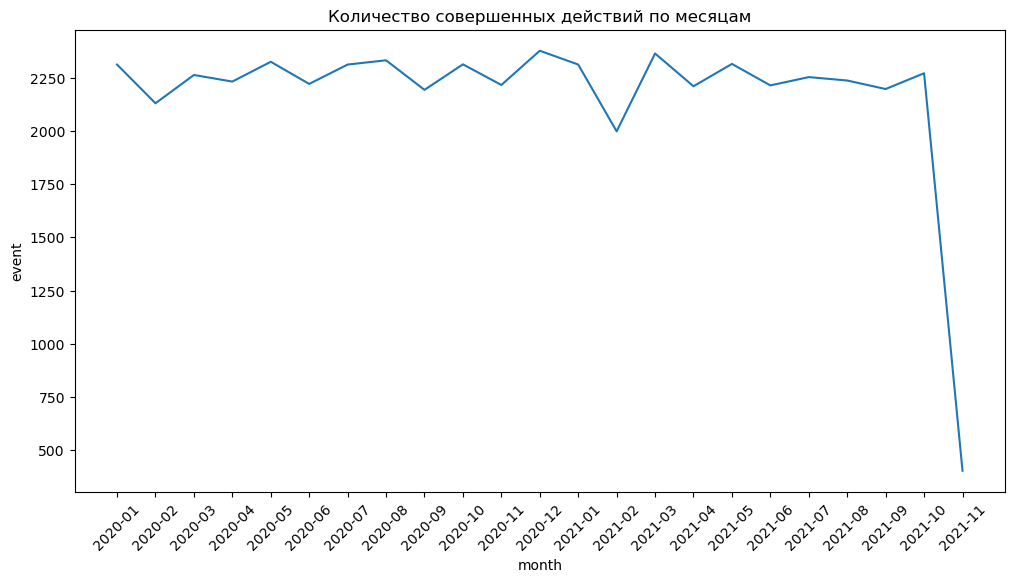

In [79]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=count_events_customers,
    x='month',
    y='event',
    ax=ax
)

ax.set_title('Количество совершенных действий по месяцам')
ax.tick_params(axis='x', rotation=45)

plt.show()


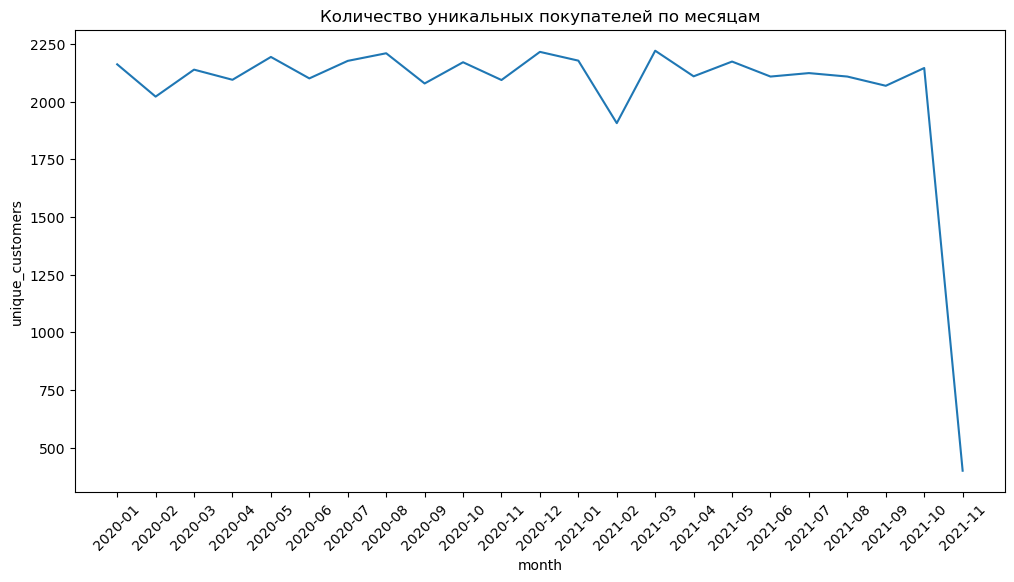

In [78]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=count_events_customers,
    x='month',
    y='unique_customers',
    ax=ax
)

ax.set_title('Количество уникальных покупателей по месяцам')
ax.tick_params(axis='x', rotation=45)

plt.show()

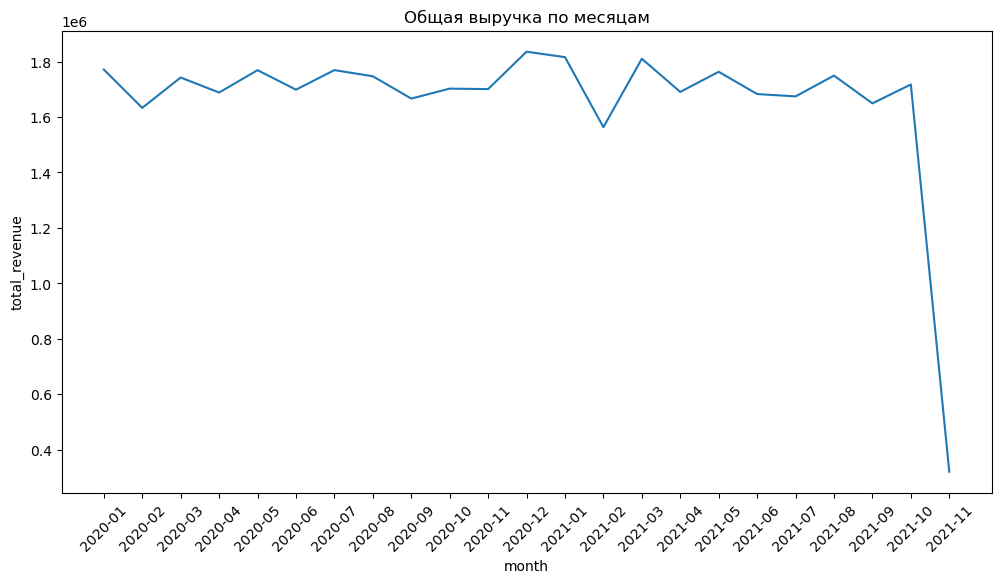

In [77]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=count_events_customers,
    x='month',
    y='total_revenue',
    ax=ax
)

ax.set_title('Общая выручка по месяцам')
ax.tick_params(axis='x', rotation=45)

plt.show()


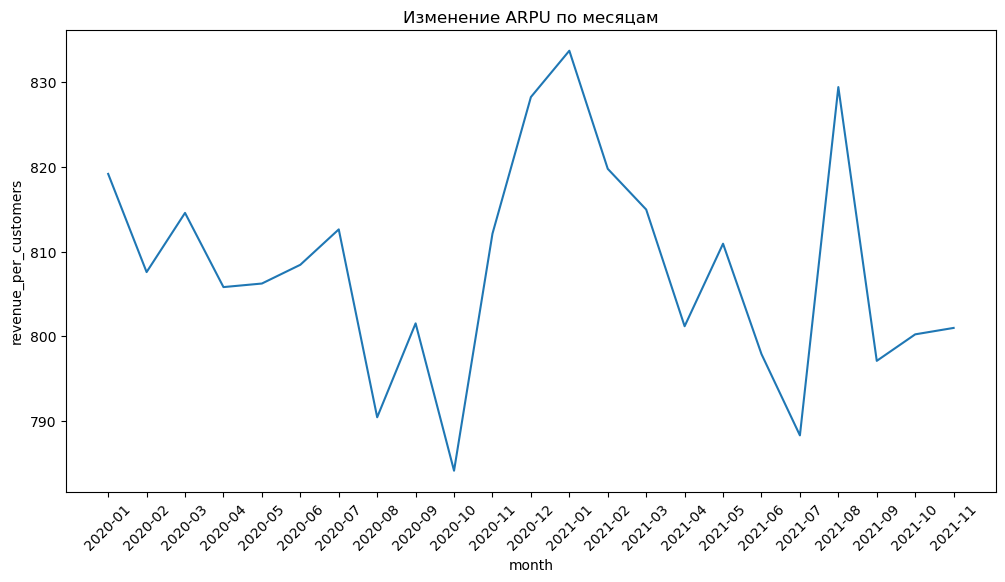

In [76]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=count_events_customers,
    x='month',
    y='revenue_per_customers',
    ax=ax
)

ax.set_title('Изменение ARPU по месяцам')
ax.tick_params(axis='x', rotation=45)

plt.show()


#### Месячная выручка меняется вслед за изменениями числа покупательских событий и кол-ва клиентов
А не из-за резкого изменения ценности 'одной' покупки

#### 2. Определим какие группы пользователей существуют

count    18389.000000
mean         2.719017
std          1.447267
min          1.000000
25%          2.000000
50%          2.000000
75%          4.000000
max         12.000000
Name: total_purchase, dtype: float64

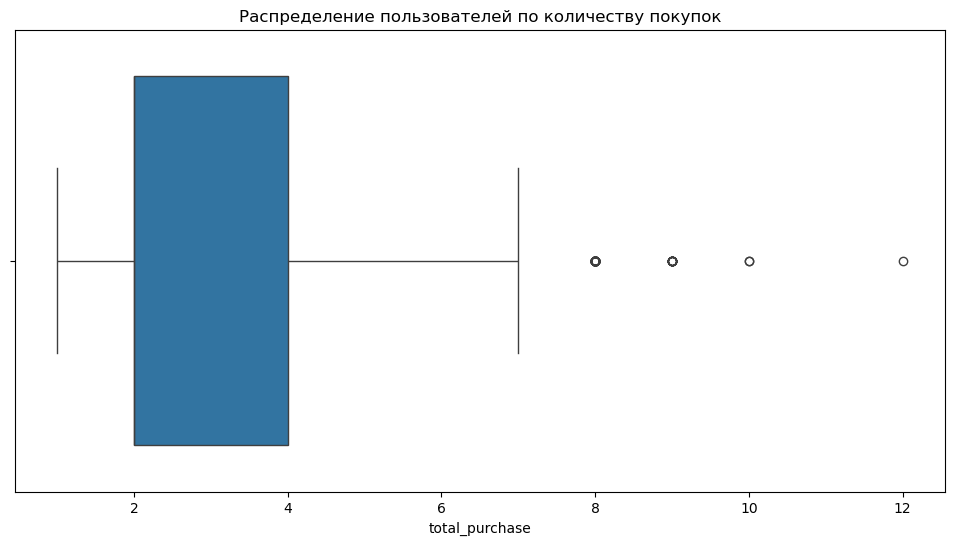

In [80]:
purchases_per_customers = ecom_df.copy()
purchases_per_customers['total_purchase'] = purchases_per_customers.groupby('customer_id')['customer_id'].count()

fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(data=purchases_per_customers,  x='total_purchase')
ax.set_title('Распределение пользователей по количеству покупок')

purchases_per_customers['total_purchase'].describe()

Text(0.5, 1.0, 'Распределение пользователей по количеству покупок')

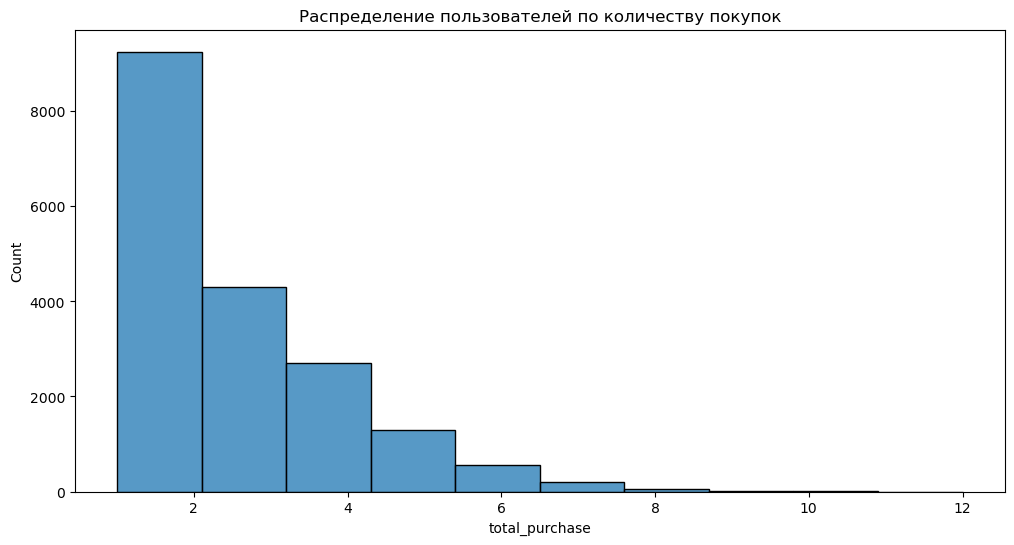

In [86]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(data=purchases_per_customers,  x='total_purchase', bins=10)
ax.set_title('Распределение пользователей по количеству покупок')

count    50000.000000
mean        43.983600
std         15.340421
min         18.000000
25%         31.000000
50%         44.000000
75%         57.000000
max         70.000000
Name: customer_age, dtype: float64

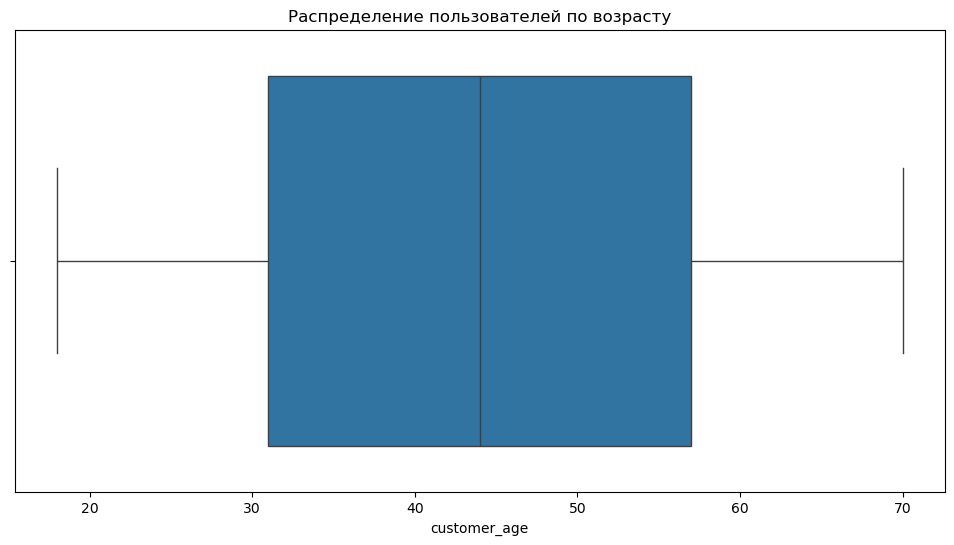

In [81]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(data=ecom_df,  x='customer_age')
ax.set_title('Распределение пользователей по возрасту')

purchases_per_customers['customer_age'].describe()

#### Полученные сегменты
**Пользователи по активности:**
* 1 покупка — one-time customers;
* 2–3 покупки — repeat customers;
* 4+ покупок — frequent customers

**Пользователи по возрасту:** '18-24', '25-34', '35-44', '45-54', '55+'

#### 3. Посмотрим разницу между группами

In [39]:
bins = [17, 24, 35, 45, 60, float('inf')]
labels = ['18-24', '25-34', '35-44', '45-54', '55+']

ecom_df['age_segment'] = pd.cut(
    ecom_df['customer_age'],
    bins=bins,
    labels=labels
)

In [88]:
#Смотрим разницу между разными группами возраста

age_segment_group = (ecom_df.groupby('age_segment', as_index=False, observed=True).agg(
    total_customers = ('customer_id', 'nunique'),
    total_revenue = ('revenue', 'sum')
))
age_segment_group['revenue_per_customer'] = age_segment_group['total_revenue'] / age_segment_group['total_customers']

age_segment_group

,age_segment,total_customers,total_revenue,revenue_per_customer
0,18-24,2491,5119958.0,2055.382577
1,25-34,3770,7753431.0,2056.612997
2,35-44,3437,7203848.0,2095.969741
3,45-54,5204,10904778.0,2095.460799
4,55+,3487,7176780.0,2058.153140


In [89]:
#Смотрим разницу между полом

gender_group = ecom_df.groupby('gender').agg(total_customers = ('customer_id', 'nunique'), total_revenue = ('revenue', 'sum'))
gender_group['revenue_per_customer'] = gender_group['total_revenue'] / gender_group['total_customers']
gender_group

,total_customers,total_revenue,revenue_per_customer
gender,,,
Female,9319,19178412.0,2057.990342
Male,9070,18980383.0,2092.655237


In [90]:
#Смотрим разницу между способом оплаты

payment_group_info = (
     ecom_df.groupby('payment_method', as_index=False)
    .agg(total_customers = ('customer_id', 'nunique'), 
         total_revenue = ('revenue', 'sum')
        ).sort_values('total_revenue', ascending=False))

payment_group_info['revenue_per_customer'] = payment_group_info['total_revenue'] / payment_group_info['total_customers']
payment_group_info

,payment_method,total_customers,total_revenue,revenue_per_customer
1,Credit Card,12691,15418304.0,1214.900638
3,PayPal,10524,11318470.0,1075.491258
0,Cash,7827,7584112.0,968.967932
2,Crypto,4375,3837909.0,877.236343


In [91]:
#Смотрим разницу между категориями товаров

category_group_info = (ecom_df.groupby('product_category')
    .agg(
        total_customers = ('customer_id', 'nunique'), 
        total_revenue = ('revenue', 'sum')
    ).sort_values('total_revenue', ascending=False))

category_group_info['revenue_per_customer'] = category_group_info['total_revenue'] / category_group_info['total_customers']
category_group_info

,total_customers,total_revenue,revenue_per_customer
product_category,,,
Books,10492,11359627.0,1082.694148
Clothing,10475,11344345.0,1082.992363
Home,7973,7769356.0,974.458297
Electronics,7979,7685467.0,963.211806


**3.1 Выводы по разницу между группами:**
1. По возрасту, выделяется группа '45-54 г.' по отношению общей выручки и общего кол-ва покупателей. Но нет особой разницы по выручке на клиента между группами
2. Явные отличия между полом покупателей не выявлены
3. Следует обратить внимание на способ оплаты 'Credit Card' - он выделяется в отношении всех показателей, в том числе и в revenue_per_customer - что может говорить о более высокой ценности клиента внутри этого способа оплаты
4. Разница между категориями товара формируется, скорее частотой покупок и масштабностью клиентской базы

Отсюда следует, что демографические признаки и категории товаров, в этом датасете слабее объясняют ценность клиента, чем поведенческие - частота покупок, способ оплаты  

## Финальные правила:
1. Одна строка — одно покупательское событие.
2. Выручка считается как product_price * quantity.
3. Повторная покупка определяется по следующей покупке клиента в более поздний день.
4. Демография пока выглядит слабее, чем поведенческие признаки.
5. Для следующего шага ключевые оси — клиент, месяц, категория, способ оплаты.